<a href="https://colab.research.google.com/github/shin-noda/deep-learning-with-python/blob/main/Chapter10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Deep Learning with Python/data'

In [5]:
import keras

model = keras.models.load_model(
    file_path + "/convnet_from_scratch_with_augmentation.keras"
)

In [6]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 7, 7, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,707,269 (17.96 MB)

 Trainable params: 1,569,089 (5.99 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 3,138,180 (11.97 MB)

In [7]:
import keras
import numpy as np

# Downloads a test image
img_path = keras.utils.get_file(
    fname="cat.jpg", origin="https://img-datasets.s3.amazonaws.com/cat.jpg"
)

def get_img_array(img_path, target_size):
    # Opens the image file and resizes it
    img = keras.utils.load_img(img_path, target_size=target_size)

    # Turns the image into a float32 NumPy array of shape (180, 180, 3)
    array = keras.utils.img_to_array(img)

    # We add a dimension to transform our array into a "batch" of a
    # single sample. Its shape is now (1, 180, 180, 3).
    array = np.expand_dims(array, axis=0)

    return array

img_tensor = get_img_array(img_path, target_size=(180, 180))

80329/80329 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


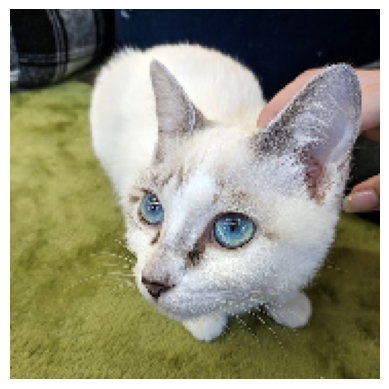

In [8]:
import matplotlib.pyplot as plt

plt.axis("off")
plt.imshow(img_tensor[0].astype("uint8"))
plt.show()

In [9]:
from keras import layers

layer_outputs = []
layer_names = []

# Extracts the outputs of all Conv2D and MaxPooling2D layers and put them in a list
for layer in model.layers:
    if isinstance(layer, (layers.Conv2D, layers.MaxPooling2D)):
        layer_outputs.append(layer.output)

        # Saves the layer names for later
        layer_names.append(layer.name)

# Creates a model that will return these outputs, given the model input
activation_model = keras.Model(inputs=model.input, outputs=layer_outputs)

In [10]:
# Returns a list of nine NumPy arrays - one array per layer activation
activations = activation_model.predict(img_tensor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step


In [11]:
first_layer_activation = activations[0]
print(first_layer_activation.shape)

(1, 178, 178, 32)


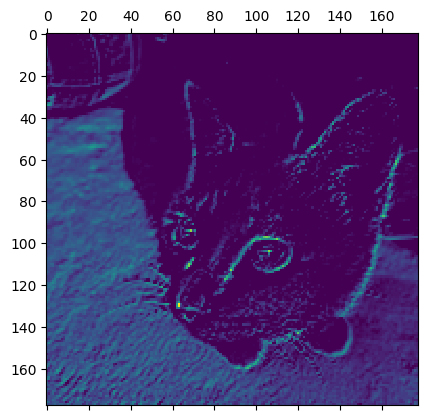

In [14]:
import matplotlib.pyplot as plt

# Plot the sixth channel of the activation of the first layer of the original model.
plt.matshow(first_layer_activation[0, :, :, 5], cmap="viridis")

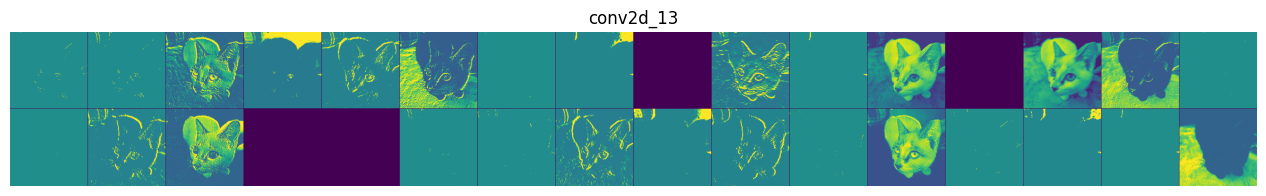

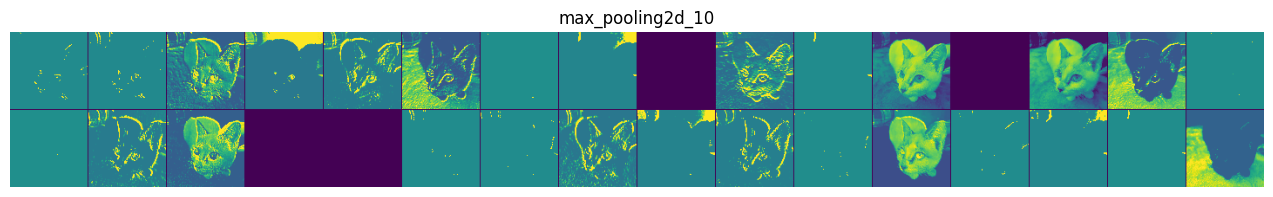

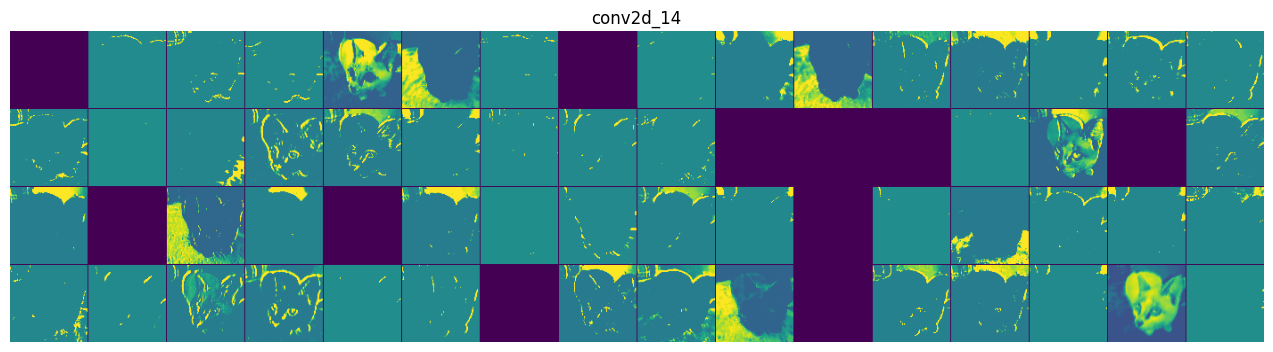

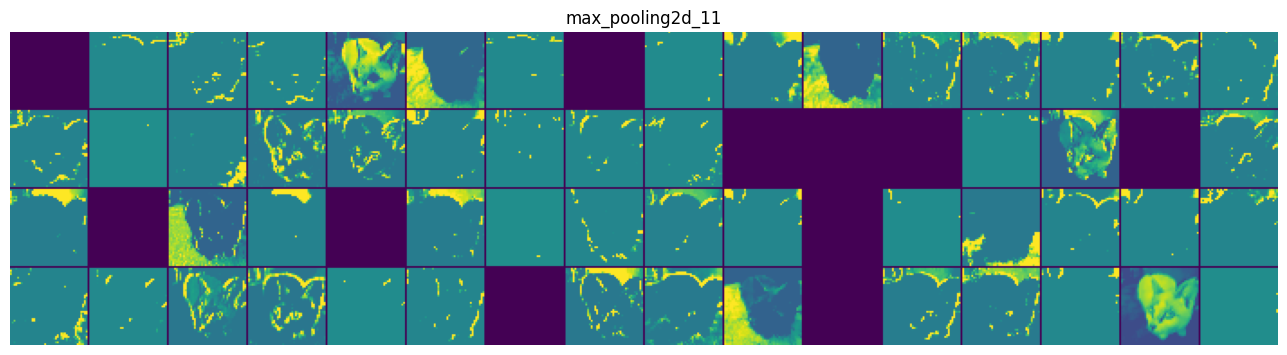

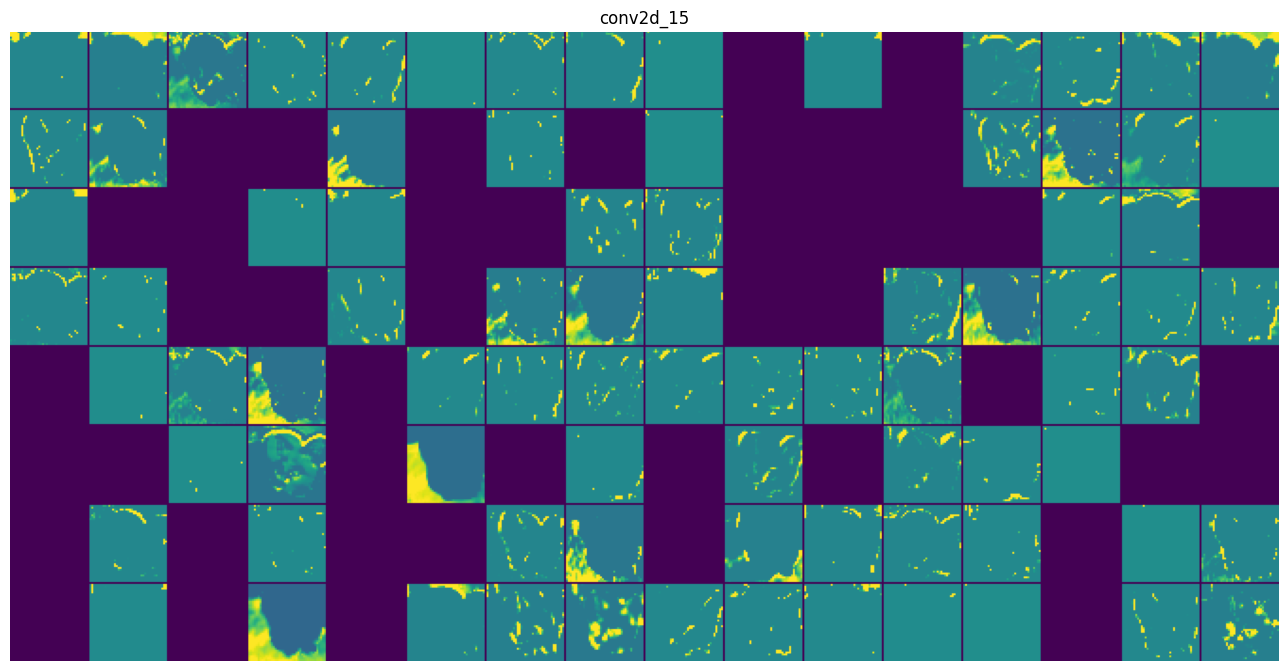

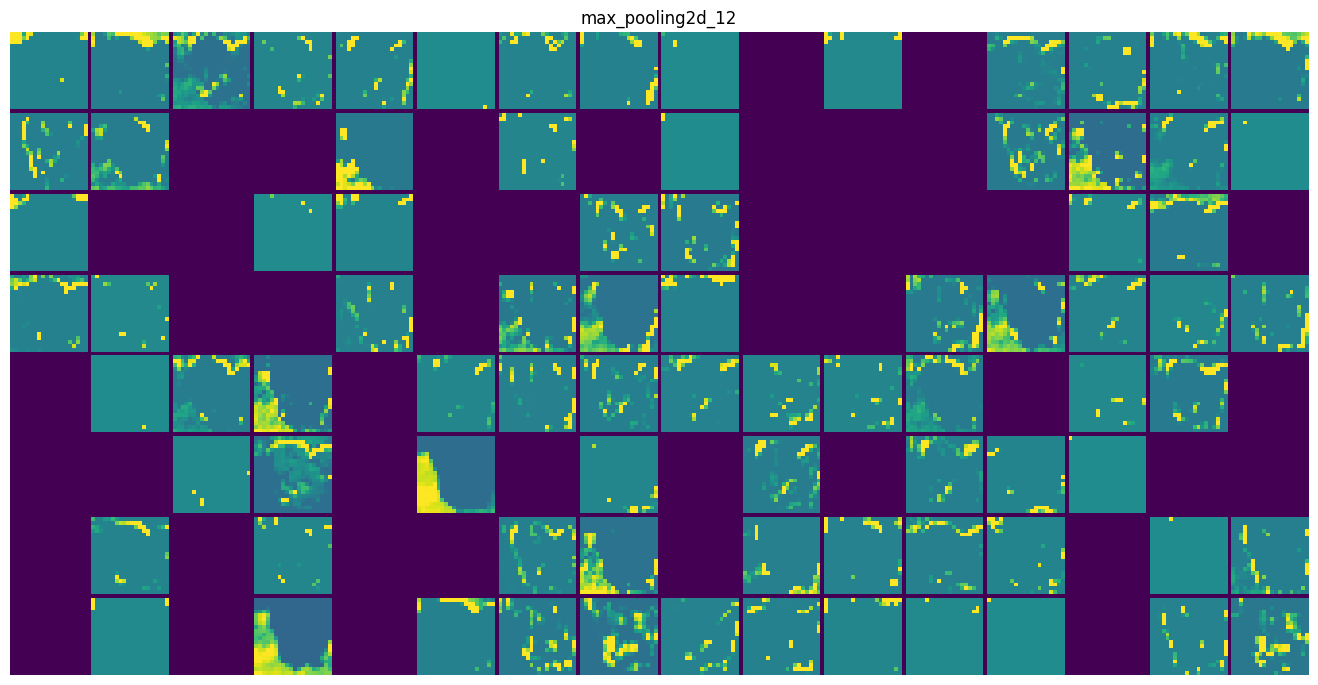

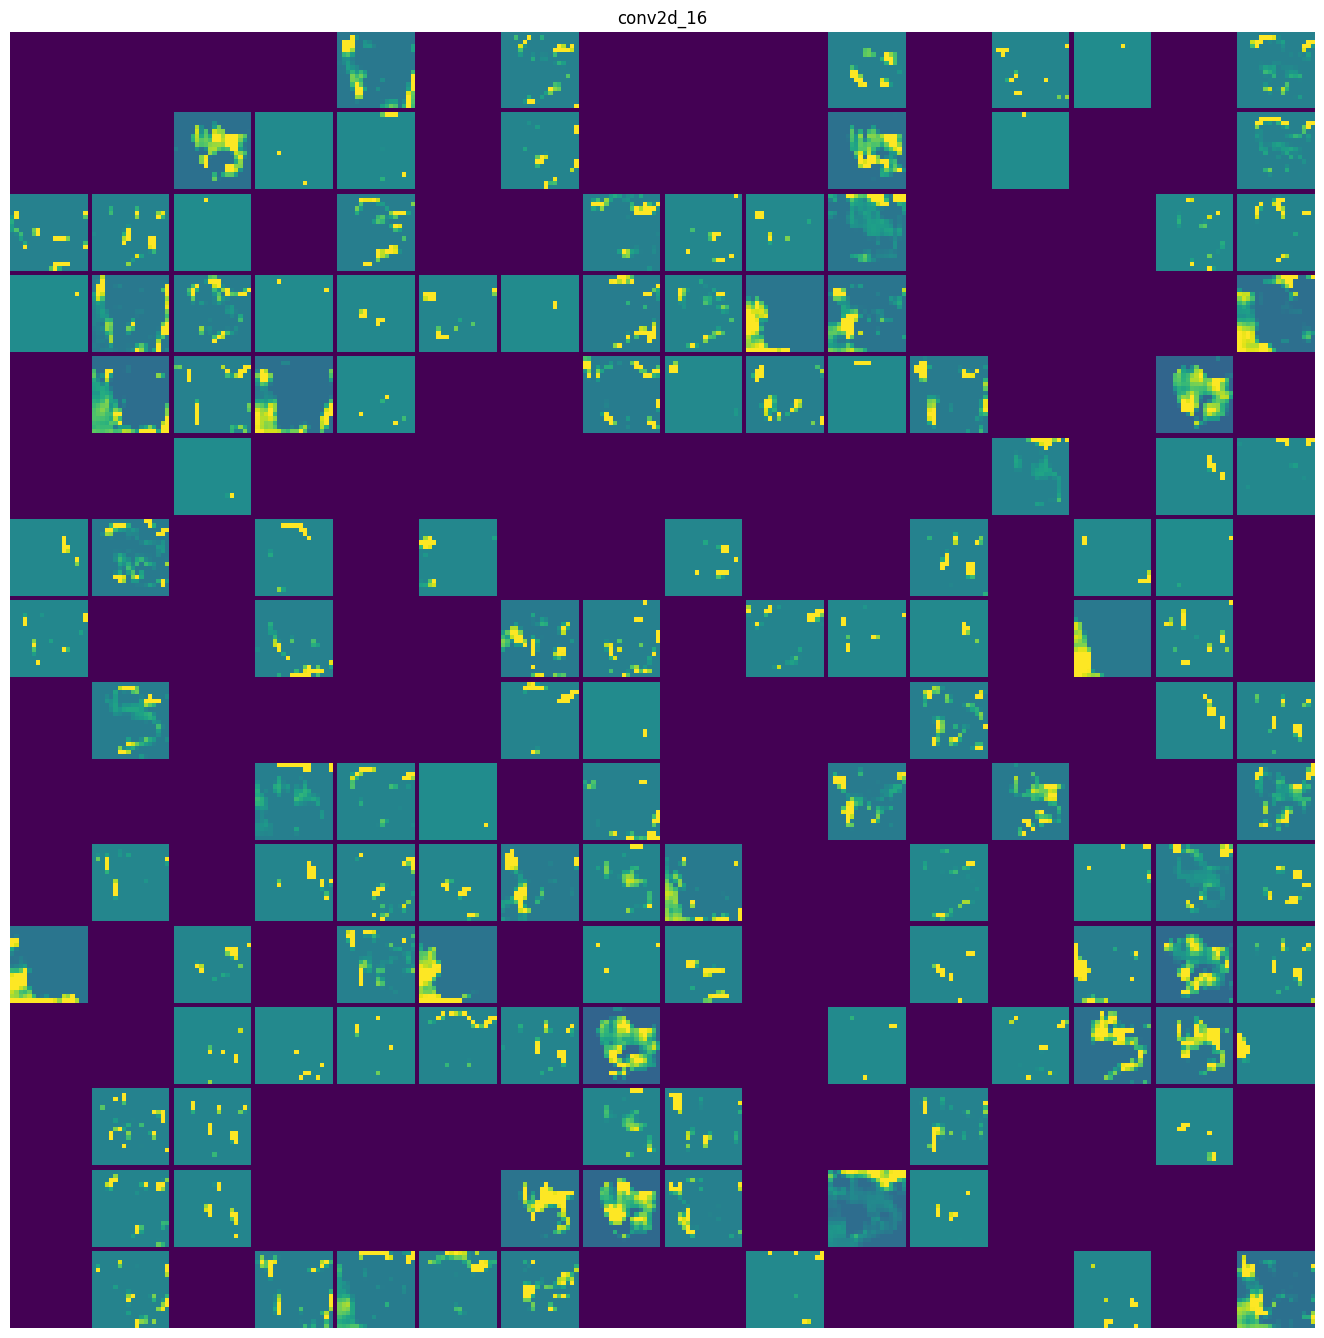

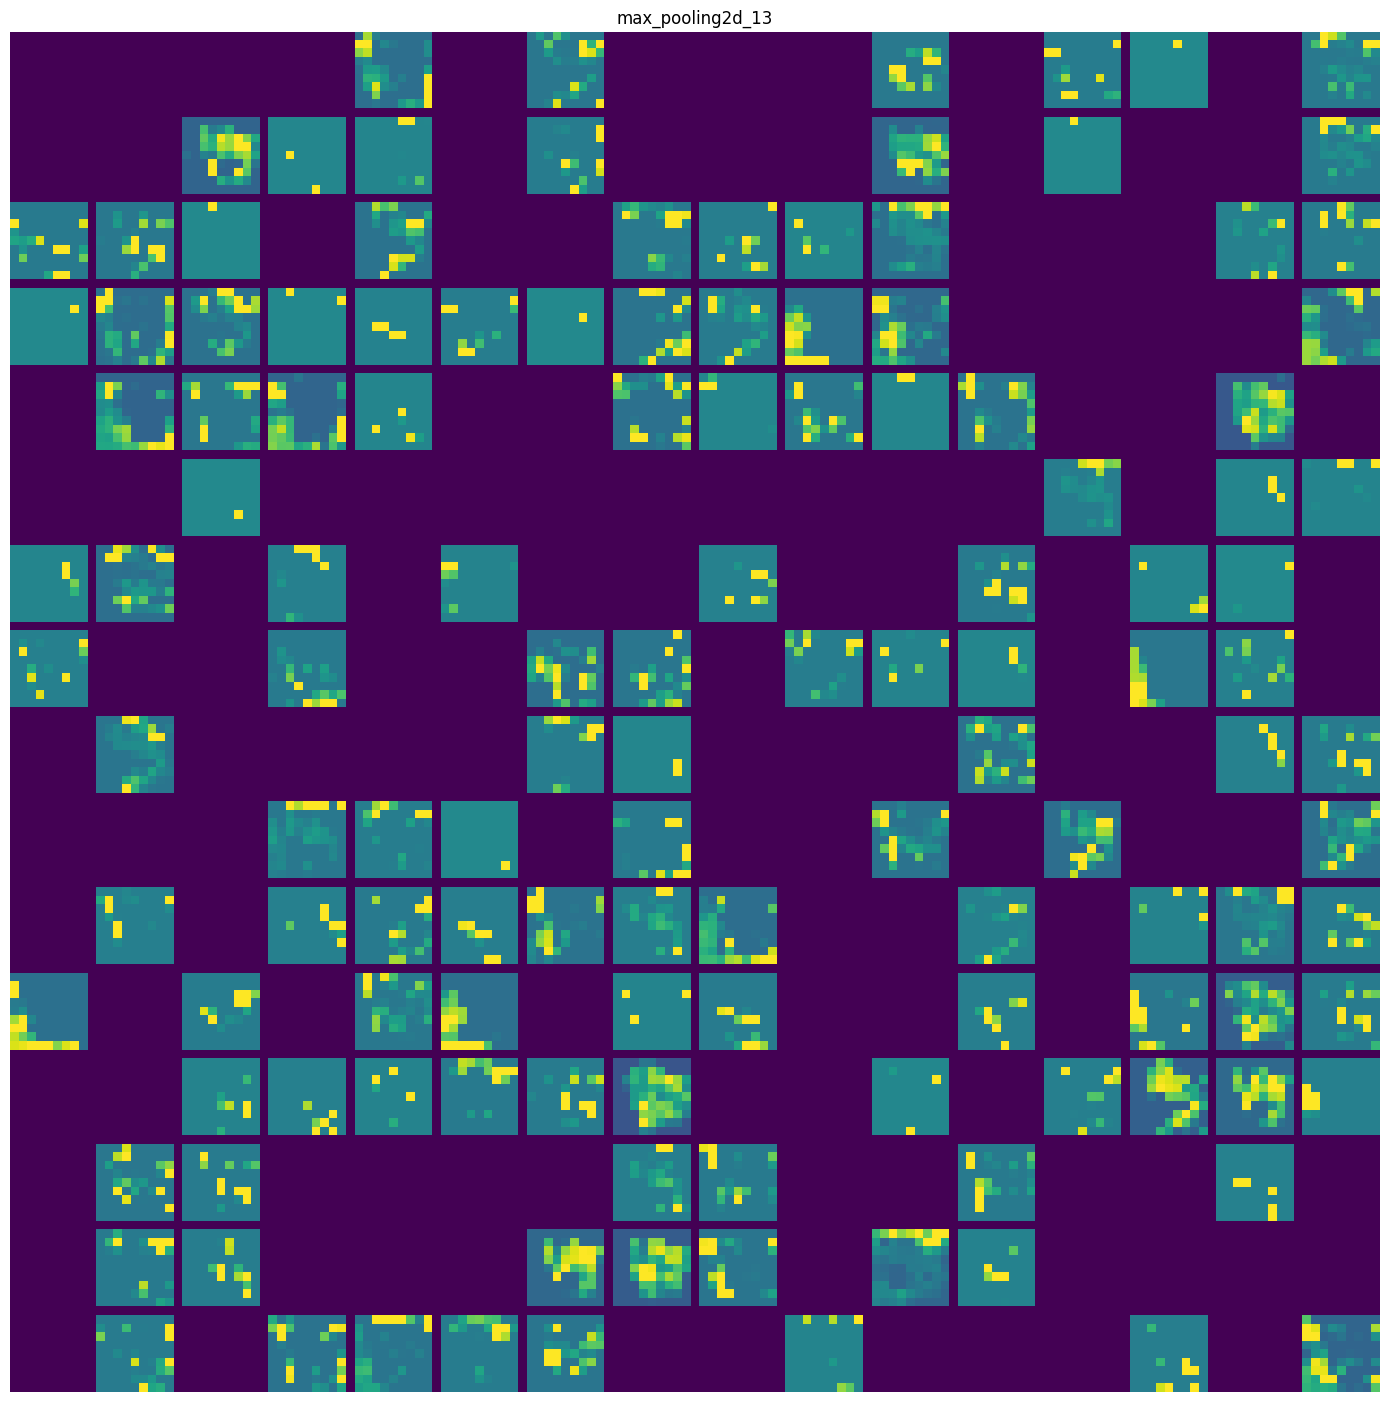

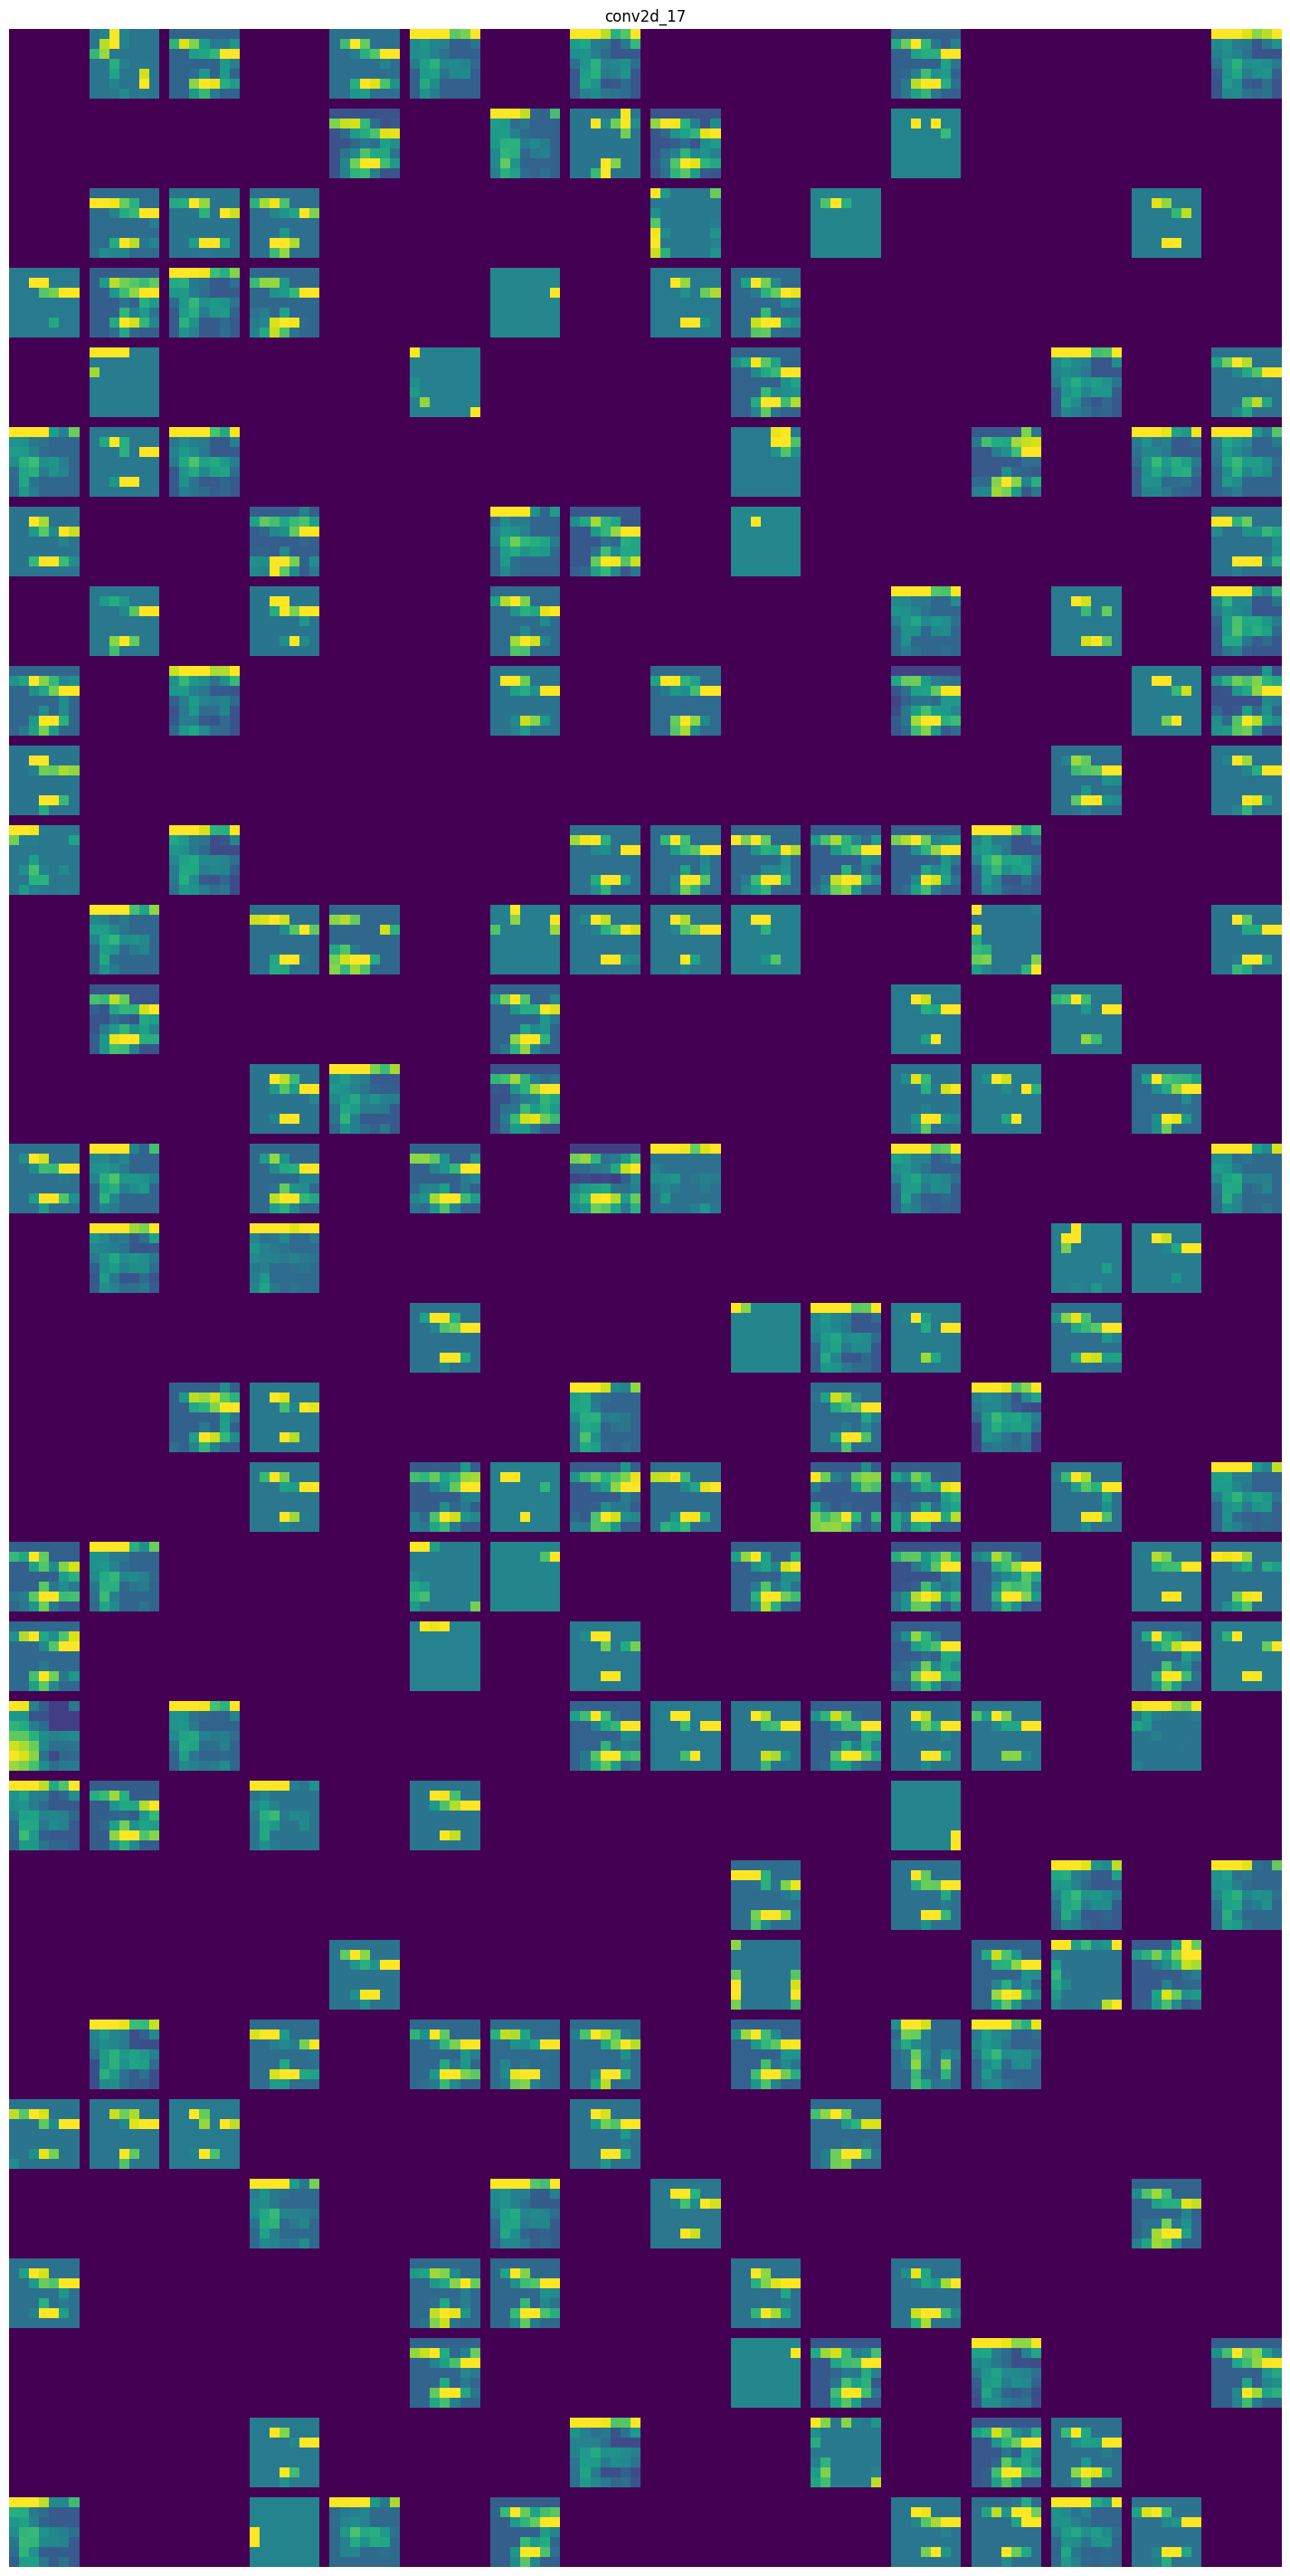

In [15]:
images_per_row = 16

# Iteraets over the activations (and the names of the corresponding layers)
for layer_name, layer_activation in zip(layer_names, activations):
    # The layer activation has shape (1, size, size, n_features).
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]
    n_cols = n_features // images_per_row

    # Prepares an empty grid for displaying all the channels in this activation
    display_grid = np.zeros(
        ((size + 1) * n_cols - 1, images_per_row * (size + 1) - 1)
    )

    for col in range(n_cols):
        for row in range(images_per_row):
            channel_index = col * images_per_row + row

            # This is a single channel (or feature).
            channel_image = layer_activation[0, :, :, channel_index].copy()

            # Normalizes channel values within the [0, 255] range.
            # All-zero channels are kept at zero.
            if channel_image.sum() != 0:
                channel_image -= channel_image.mean()
                channel_image /= channel_image.std()
                channel_image *= 64
                channel_image += 128

            channel_image = np.clip(channel_image, 0, 255).astype("uint8")

            # Places the channel matrix in the empty grid we prepared
            display_grid[
                col * (size + 1) : (col + 1) * size + col,
                row * (size + 1) : (row + 1) * size + row,
            ] = channel_image

    # Displays the grid for the layer
    scale = 1.0 / size
    plt.figure(
        figsize=(scale * display_grid.shape[1], scale * display_grid.shape[0])
    )

    plt.title(layer_name)
    plt.grid(False)
    plt.axis("off")
    plt.imshow(display_grid, aspect="auto", cmap="viridis")

In [16]:
import keras_hub

# Instantiates the feature extactor network from pretrained weights
model = keras_hub.models.Backbone.from_preset(
    "xception_41_imagenet",
)

# Loads the matching preprocessing to scale our input images
preprocessor = keras_hub.layers.ImageConverter.from_preset(
    "xception_41_imagenet",
    image_size=(180, 180),
)

100%|██████████| 1.79k/1.79k [00:00<00:00, 663kB/s]


100%|██████████| 79.9M/79.9M [00:00<00:00, 109MB/s]


In [17]:
for layer in model.layers:
    if isinstance(layer, (keras.layers.Conv2D, keras.layers.SeparableConv2D)):
        print(layer.name)

block1_conv1
block1_conv2
block2_sepconv1
block2_sepconv2
block2_residual_conv
block3_sepconv1
block3_sepconv2
block3_residual_conv
block4_sepconv1
block4_sepconv2
block4_residual_conv
block5_sepconv1
block5_sepconv2
block5_sepconv3
block6_sepconv1
block6_sepconv2
block6_sepconv3
block7_sepconv1
block7_sepconv2
block7_sepconv3
block8_sepconv1
block8_sepconv2
block8_sepconv3
block9_sepconv1
block9_sepconv2
block9_sepconv3
block10_sepconv1
block10_sepconv2
block10_sepconv3
block11_sepconv1
block11_sepconv2
block11_sepconv3
block12_sepconv1
block12_sepconv2
block12_sepconv3
block13_sepconv1
block13_sepconv2
block13_residual_conv
block14_sepconv1
block14_sepconv2


In [18]:
# You could replace this with the name of any layer in the Xception convolutional base.
layer_name = "block3_sepconv1"

# This is the layer object we're interested in.
layer = model.get_layer(name=layer_name)

# We use model.input and layer.output to create a model that, given an
# input iamge, returns the output of our target layer.
feature_extractor = keras.Model(inputs=model.input, outputs=layer.output)

In [19]:
activation = feature_extractor(preprocessor(img_tensor))

In [20]:
from keras import ops

# The loss function takes an image tensor and the index of the filter we consider (an integer).
def compute_loss(image, filter_index):
    activation = feature_extractor(image)

    # We avoid border artifacts by only involving nonborder pixels in the loss:
    # we discard the first 2 pixels along the sides of the activation.
    filter_activation = activation[:, 2:-2, 2:-2, filter_index]

    # Returns the mean of the activation values for the filter
    return ops.mean(filter_activation)

In [22]:
# Gradient ascent in TensorFlow

In [23]:
import tensorflow as tf

@tf.function
def gradient_ascent_step(image, filter_index, learning_rate):
    with tf.GradientTape() as tape:
        # Explicitlhy watches the image tensor, since it isn't a
        # TensorFlow Variable (only Variables are automatically watched in a gradient tape)
        tape.watch(image)

        # Computes the loss scalar, indicating how much the current image activates the filter
        loss = compute_loss(image, filter_index)

    # Computes the gradients of the loss with respect to the image
    grads = tape.gradient(loss, image)

    # Applies the "gradient normalization trick"
    grads = ops.normalize(grads)

    # Moves the image a little bit in a direction that activates our target filter more strongly
    image += learning_rate * grads

    # Returns the updated image, so we can run the step function in a loop
    return image

In [29]:
# The filter visualization loop
img_width = 200
img_height = 200

def generate_filter_pattern(filter_index):
    # The number of gradient ascent steps to apply
    iterations = 30

    # The amplitude of a single step
    learning_rate = 10.0
    image = keras.random.uniform(
        # Initialize an image tensor with random values.
        # (The Xception model expects input values in the [0, 1] range,
        # so here we pick a range centered on 0.5.)
        minval=0.4, maxval=0.6, shape=(1, img_width, img_height, 3)
    )

    # Repeatedly updates the values of the image tensor to maximize our loss function
    for i in range(iterations):
        image = gradient_ascent_step(image, filter_index, learning_rate)

    return image[0]

In [30]:
def deprocess_image(image):
    # Normalizes image values within the [0, 255] range
    image -= ops.mean(image)
    image /= ops.std(image)
    image *= 64
    image += 128
    image = ops.clip(image, 0, 255)

    # Center crop to avoid border artifacts
    image = image[25:-25, 25:-25, :]
    image = ops.cast(image, dtype="uint8")

    return ops.convert_to_numpy(image)

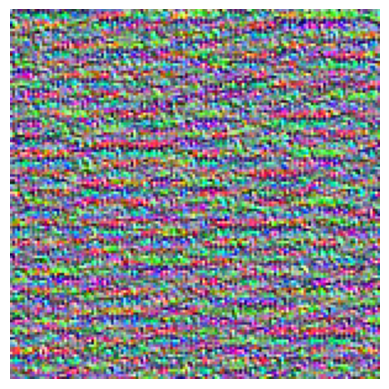

In [31]:
plt.axis("off")
plt.imshow(deprocess_image(generate_filter_pattern(filter_index=2)))

In [34]:
# Generates and saves visualizations for the first 64 filters in the layer
all_images = []
for filter_index in range(64):
    print(f"Processing filter {filter_index}")
    image = deprocess_image(generate_filter_pattern(filter_index))
    all_images.append(image)

# Prepares a blank canvas for us to paste filter visualizations
margin = 5
n = 8
box_width = img_width - 25 * 2
box_height = img_height - 25 * 2
full_width = n * box_width + (n - 1) * margin
full_height = n * box_height + (n - 1) * margin
stitched_filters = np.zeros((full_width, full_height, 3))

# Fills the picture with our saved filters
for i in range(n):
    for j in range(n):
        image = all_images[i * n + j]
        stitched_filters[
            (box_width + margin) * i : (box_width + margin) * i + box_width,
            (box_height + margin) * j : (box_height + margin) * j + box_height,
            :,
        ] = image

# Saves the canvas to disk
keras.utils.save_img(f"filters_for layers_{layer_name}.png", stitched_filters)

Processing filter 0
Processing filter 1
Processing filter 2
Processing filter 3
Processing filter 4
Processing filter 5
Processing filter 6
Processing filter 7
Processing filter 8
Processing filter 9
Processing filter 10
Processing filter 11
Processing filter 12
Processing filter 13
Processing filter 14
Processing filter 15
Processing filter 16
Processing filter 17
Processing filter 18
Processing filter 19
Processing filter 20
Processing filter 21
Processing filter 22
Processing filter 23
Processing filter 24
Processing filter 25
Processing filter 26
Processing filter 27
Processing filter 28
Processing filter 29
Processing filter 30
Processing filter 31
Processing filter 32
Processing filter 33
Processing filter 34
Processing filter 35
Processing filter 36
Processing filter 37
Processing filter 38
Processing filter 39
Processing filter 40
Processing filter 41
Processing filter 42
Processing filter 43
Processing filter 44
Processing filter 45
Processing filter 46
Processing filter 47
Pr

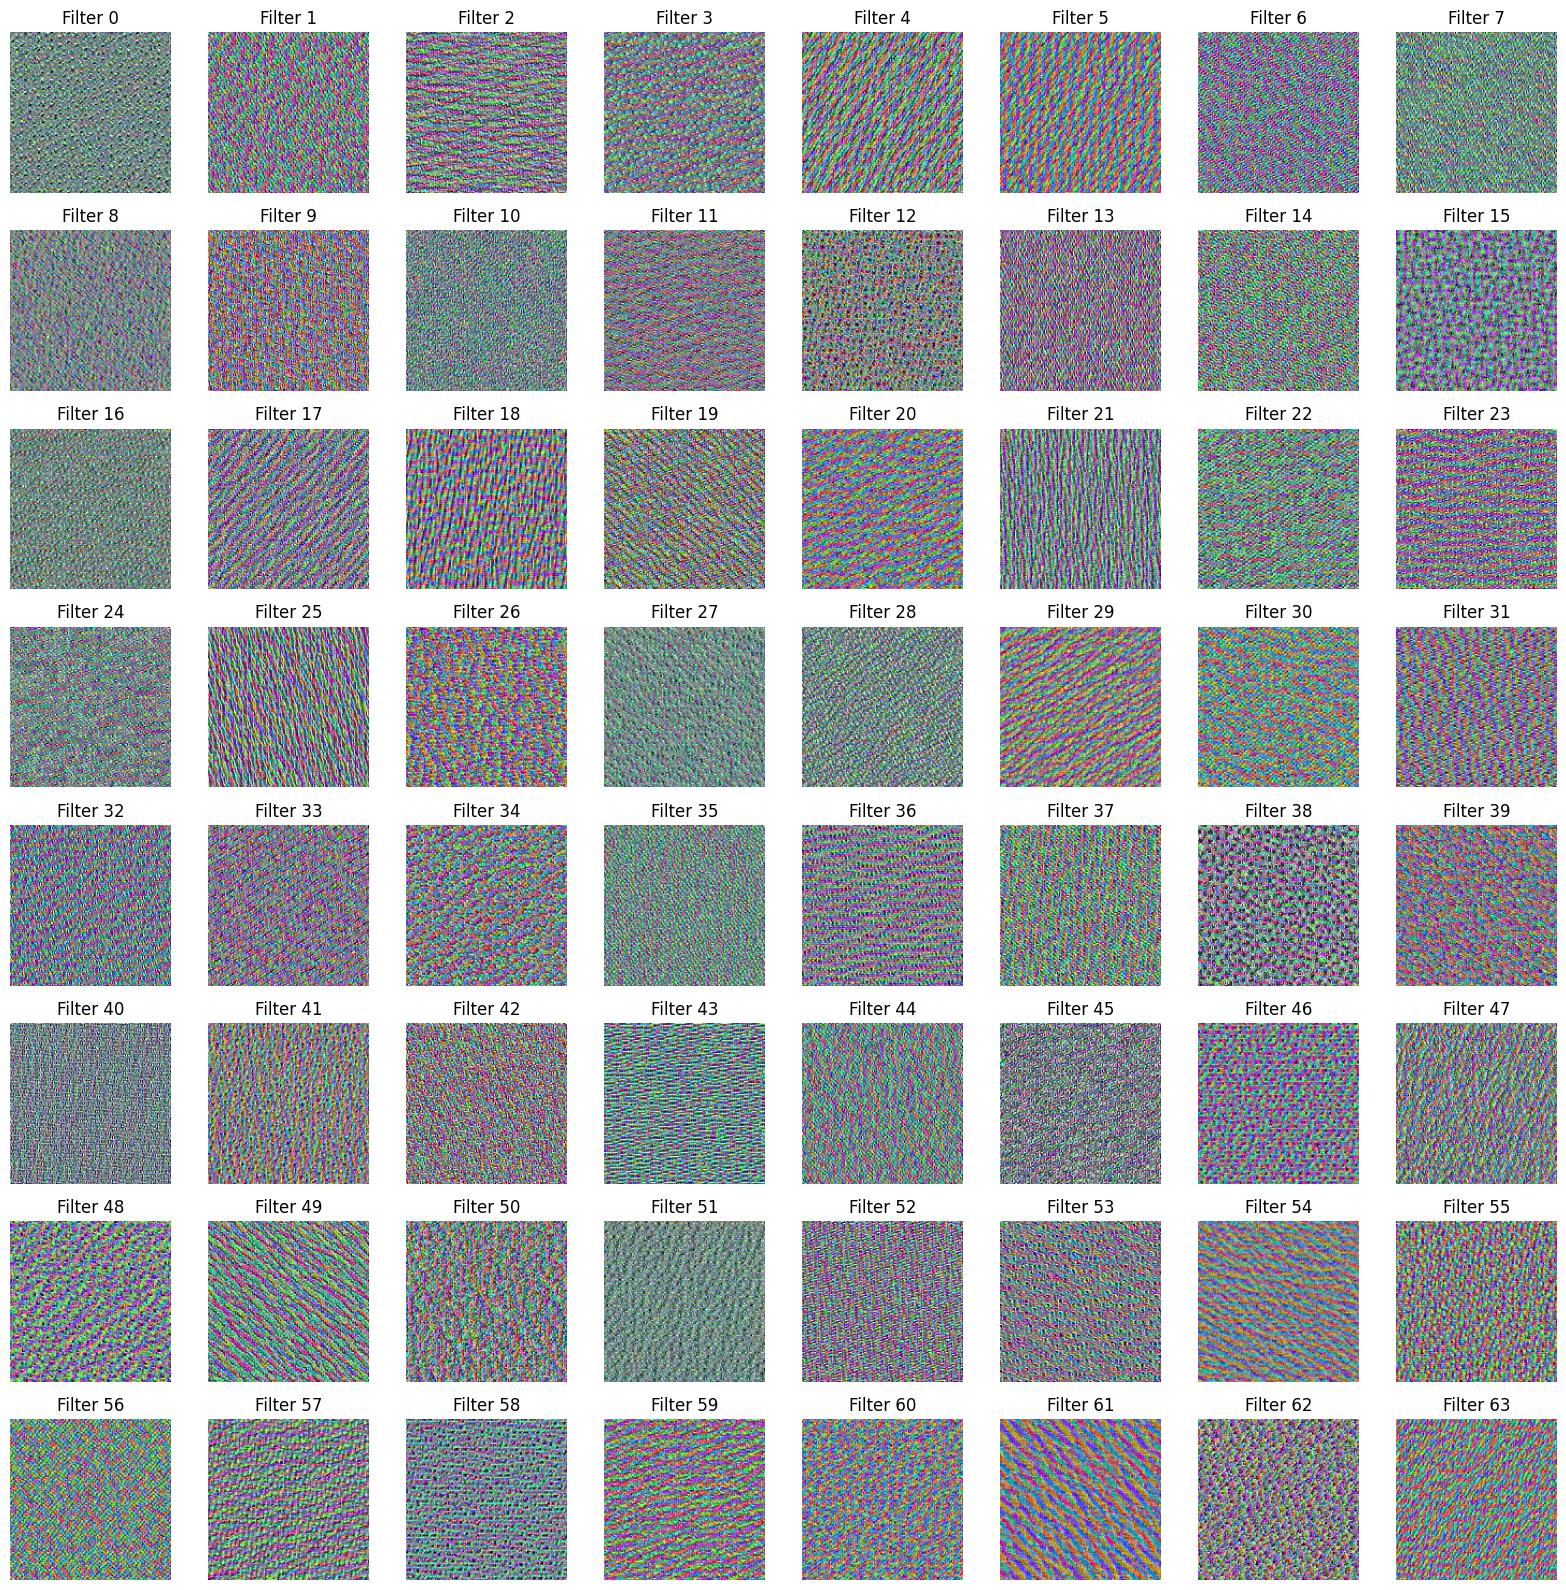

In [37]:
images_per_row = 8
n_images = len(all_images)
n_rows = (n_images + images_per_row - 1) // images_per_row

fig, axes = plt.subplots(
    n_rows,
    images_per_row,
    figsize=(16, 16)
)

axes = np.array(axes).reshape(n_rows, images_per_row)

for i, image in enumerate(all_images):
    row = i // images_per_row
    col = i % images_per_row

    axes[row, col].imshow(image.astype("uint8"))
    axes[row, col].axis("off")
    axes[row, col].set_title(f"Filter {i}")

# Hide unused cells
for i in range(n_images, n_rows * images_per_row):
    row = i // images_per_row
    col = i % images_per_row
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [38]:
# Visualizing heatmaps of class activation

In [39]:
# Downloads the image and stores it locally under the path img_path
img_path = keras.utils.get_file(
    fname="elephant.jpg",
    origin="https://img-datasets.s3.amazonaws.com/elephant.jpg",
)

# Returns a Python Imaging Library (PIL) image
img = keras.utils.load_img(img_path)
img_array = np.expand_dims(img, axis=0)

733657/733657 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [41]:
model = keras_hub.models.ImageClassifier.from_preset(
    "xception_41_imagenet",

    # We can configure the final activation of the classifier.
    # Here, we use a softmax activation so our outputs are probabilities.
    activation="softmax",
)

preds = model.predict(img_array)

# ImageNet has 1000 classes, so each prediction from our classifier has 1000 entries.
preds.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


(1, 1000)

In [43]:
keras_hub.utils.decode_imagenet_predictions(preds)

[[('African_elephant', 0.903317928314209),
  ('tusker', 0.05487099289894104),
  ('Indian_elephant', 0.016378749161958694),
  ('triceratops', 0.00029663313762284815),
  ('Mexican_hairless', 0.00018873176304623485)]]

In [44]:
np.argmax(preds[0])

np.int64(386)

In [45]:
# KerasHub tasks like ImageClassifier have a preprocessor layer.
img_array = model.preprocessor(img_array)

In [50]:
# We create a model that maps the input image to the activations of the last convolutional layer.
last_conv_layer_name = "block14_sepconv2_act"
last_conv_layer = model.backbone.get_layer(last_conv_layer_name)
last_conv_layer_model = keras.Model(model.inputs, last_conv_layer.output)

In [51]:
# We create a model that maps the activations of the last convolutional layer to the final class predictions.
classifier_input = last_conv_layer.output
x = classifier_input
for layer_name in ["pooler", "predictions"]:
    x = model.get_layer(layer_name)(x)

classifier_model = keras.Model(classifier_input, x)

In [58]:
# Getting the gradient of the top class: TensorFlow version
import tensorflow as tf

def get_top_class_gradients(img_array):
    # Computes activations of the last conv layer and ameks the tape watch it
    last_conv_layer_output = last_conv_layer_model(img_array)
    with tf.GradientTape() as tape:
        tape.watch(last_conv_layer_output)
        preds = classifier_model(last_conv_layer_output)
        top_pred_index = ops.argmax(preds[0])

        # Retrieves the activation channel corresponding to the top predicted class
        top_class_channel = preds[:, top_pred_index]

    # Gets the gradient of the top predicted class with regard to the
    # output feature map of the last convolutional layer
    grads = tape.gradient(top_class_channel, last_conv_layer_output)

    return grads, last_conv_layer_output

grads, last_conv_layer_output = get_top_class_gradients(img_array)
grads = ops.convert_to_numpy(grads)
last_conv_layer_output = ops.convert_to_numpy(last_conv_layer_output)

In [59]:
# Displaying the class activation heatmap
# This is a vector where each entry is the mean intensity of the gradient for a given channel.
# It quantifies the importance of each channel with regard to the top predicted class.
pooled_grads = np.mean(grads, axis=(0, 1, 2))
last_conv_layer_output = last_conv_layer_output[0].copy()

# Multiplies each channel in the output of the last convolutional layer
# by how important this channel is
for i in range(pooled_grads.shape[-1]):
    last_conv_layer_output[:, :, i] *= pooled_grads[i]

# The channel-wise mean of the resulting feature map is our heatmap of class activation
heatmap = np.mean(last_conv_layer_output, axis=-1)

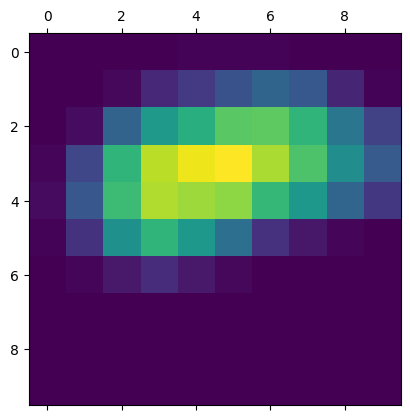

In [61]:
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)
plt.matshow(heatmap)

/tmp/ipykernel_1628/1533743097.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  jet = cm.get_cmap("jet")


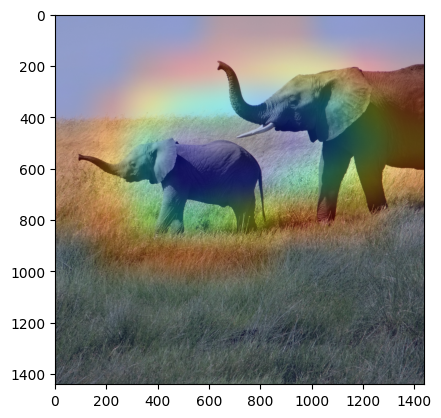

In [65]:
# Generate an image that superimposes the original image on the heapmap
import matplotlib.cm as cm

# Loads the original image
img = keras.utils.load_img(img_path)
img = keras.utils.img_to_array(img)

# Rescales the heatmap to the range 0-255
heatmap = np.uint8(255 * heatmap)

# Uses the "jet" colormap to recolorize the heatmap
jet = cm.get_cmap("jet")
jet_colors = jet(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap]

# Creates an image that contains the recolorized heatmap
jet_heatmap = keras.utils.array_to_img(jet_heatmap)
jet_heatmap = jet_heatmap.resize((img.shape[1], img.shape[0]))
jet_heatmap = keras.utils.img_to_array(jet_heatmap)

# Superimposes the heatmap and the original image, with the heatmap at 40% opacity
superimposed_img = jet_heatmap * 0.4 + img
superimposed_img = keras.utils.array_to_img(superimposed_img)

# Shows the superimposed image
plt.imshow(superimposed_img)